# Eye Disease Classification

## Data Preprocessing and Cleansing

This notebook performs exploratory analysis, quality assessment, and preprocessing of the eye disease image dataset. The objective is to prepare a consistent and reliable dataset for future model training while preserving the integrity of the original data.

The preprocessing pipeline includes the following stages:

1. Dataset structure verification  
2. Image count and class distribution analysis  
3. Image format verification  
4. Empty file detection  
5. Image quality assessment (aspect ratio, brightness, and blur)  
6. Removal of corrupted or low-quality images  
7. Image dimension and resolution analysis  
8. Duplicate image detection  
9. Image resizing to a uniform dimension  
10. Pixel value normalization  
11. Random image visualization for visual inspection  
12. Final dataset statistics and validation

For each preprocessing step, statistical summaries and visualizations are generated to justify the transformation applied to the dataset.

The original dataset remains unchanged, and a cleaned dataset is generated separately to ensure reproducibility and data integrity.

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import imagehash
import random

sns.set_style("whitegrid")

### The dataset is organized into training and validation folders with class-based subdirectories.

In [2]:
# Artifacts (art): from nbs/ use ../art
ART_ROOT = os.path.join("..", "art")
if not os.path.isdir(ART_ROOT):
    raise FileNotFoundError(
        f"Artifacts folder not found: {os.path.abspath(ART_ROOT)}\n"
        "Create it at project root (e.g. art/raw/train, art/raw/validate)."
    )

# art/raw: train and validate (input)
raw_train_dir = os.path.join(ART_ROOT, "raw", "train")
raw_val_dir = os.path.join(ART_ROOT, "raw", "validate")

# art/clean: train and validate (output)
clean_root = os.path.join(ART_ROOT, "clean")
clean_train_dir = os.path.join(ART_ROOT, "clean", "train")
clean_val_dir = os.path.join(ART_ROOT, "clean", "validate")

os.makedirs(clean_train_dir, exist_ok=True)
os.makedirs(clean_val_dir, exist_ok=True)

### Verifying that the dataset directory contains the expected folder structure and class labels.

In [3]:
print("Train Classes:", os.listdir(raw_train_dir))
print("Validation Classes:", os.listdir(raw_val_dir))

Train Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Validation Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


### Removal of macOS System Files (.DS_Store)

In [4]:
def remove_ds_store(root_dir):
    removed = 0
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file == ".DS_Store":
                path = os.path.join(root, file)
                os.remove(path)
                removed += 1
    return removed


removed_train = remove_ds_store(raw_train_dir)
removed_val = remove_ds_store(raw_val_dir)

print(f".DS_Store removed from Train: {removed_train}")
print(f".DS_Store removed from Val: {removed_val}")

.DS_Store removed from Train: 0
.DS_Store removed from Val: 0


### Understanding the number of images per class helps identify class imbalance.

Train Distribution: {'cataract': 1018, 'diabetic_retinopathy': 1086, 'glaucoma': 987, 'normal': 1054}
Validation Distribution: {'cataract': 20, 'diabetic_retinopathy': 13, 'glaucoma': 20, 'normal': 20}


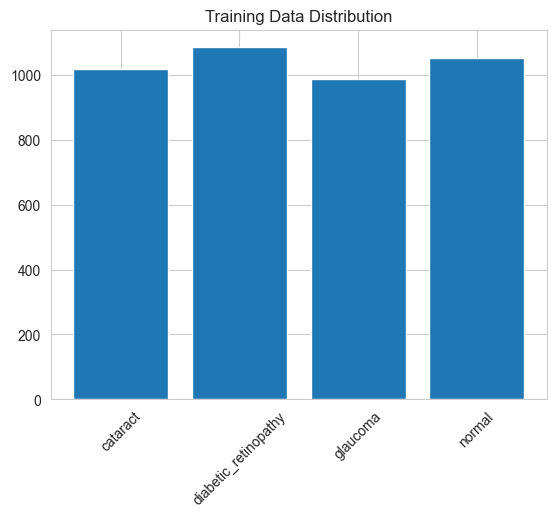

In [5]:
def count_images(directory):
    counts = {}
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(raw_train_dir)
val_counts = count_images(raw_val_dir)

print("Train Distribution:", train_counts)
print("Validation Distribution:", val_counts)

plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Distribution")
plt.xticks(rotation=45)
plt.show()

### Verifying that images are stored in valid formats such as JPG, JPEG, or PNG.

In [6]:
formats = {}

for root, dirs, files in os.walk(raw_train_dir):
    for file in files:
        ext = file.split(".")[-1].lower()
        formats[ext] = formats.get(ext,0) + 1

formats

{'jpg': 2864, 'png': 195, 'jpeg': 1086}

### Detecting images that have zero file size which indicates incomplete or corrupted files.

In [7]:
empty_files = []

for root, dirs, files in os.walk(raw_train_dir):
    for file in files:
        path = os.path.join(root,file)
        if os.path.getsize(path) == 0:
            empty_files.append(path)

print("Empty files:", len(empty_files))

Empty files: 0


### Image Quality Assessment

Image quality is evaluated before selecting images for the cleaned dataset.  
Three measurable quality indicators are analyzed:

1. Aspect Ratio Consistency  
2. Image Brightness Distribution  
3. Image Sharpness (Blur Detection)

Statistical summaries and visualizations are generated to understand the distribution of these metrics across the dataset. These measurements help justify the thresholds used for filtering low-quality images.

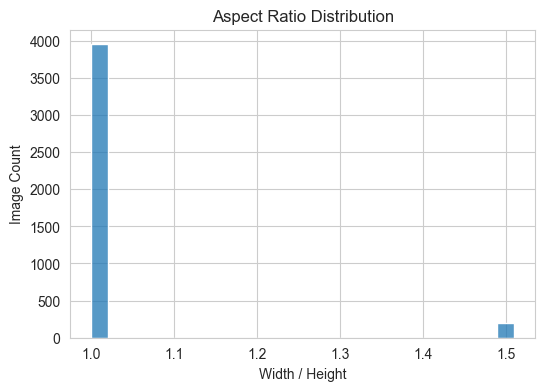

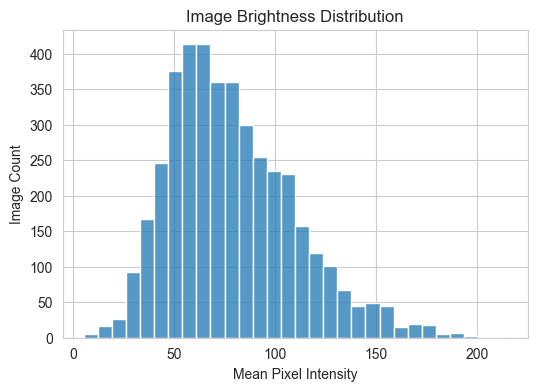

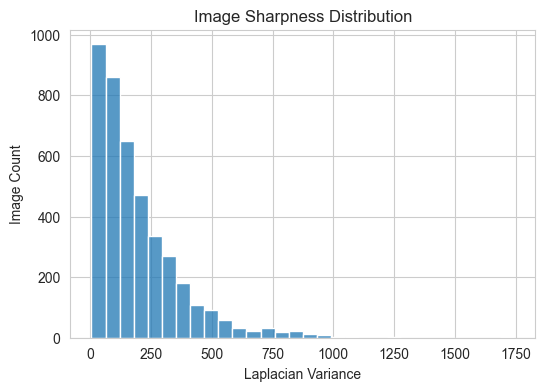

In [8]:
# Quality Metrics Extraction
# --------------------------
aspect_ratios = []
brightness_values = []
blur_scores = []

for root, dirs, files in os.walk(raw_train_dir):

    for file in files:

        path = os.path.join(root, file)
        img = cv2.imread(path)

        if img is None:
            continue

        h, w = img.shape[:2]

        aspect_ratio = w / h
        aspect_ratios.append(aspect_ratio)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)
        brightness_values.append(brightness)

        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        blur_scores.append(blur_score)

# Statistical Summary
# -------------------
quality_stats = pd.DataFrame({
    "Aspect Ratio": aspect_ratios,
    "Brightness": brightness_values,
    "Blur Score": blur_scores
})

quality_stats.describe()

# Aspect Ratio Distribution
# -------------------------
plt.figure(figsize=(6,4))
sns.histplot(aspect_ratios, bins=25)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Image Count")

plt.show()

# Brightness Distribution
# -----------------------
plt.figure(figsize=(6,4))
sns.histplot(brightness_values, bins=30)

plt.title("Image Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Image Count")

plt.show()

# Blur Score Distribution
# -----------------------
plt.figure(figsize=(6,4))
sns.histplot(blur_scores, bins=30)

plt.title("Image Sharpness Distribution")
plt.xlabel("Laplacian Variance")
plt.ylabel("Image Count")

plt.show()

# Quality Filtering Function
# --------------------------
def image_quality_check(img):

    h, w = img.shape[:2]

    aspect_ratio = w / h

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)

    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Aspect ratio filtering
    if aspect_ratio < 0.7 or aspect_ratio > 1.3:
        return False

    # Brightness filtering
    if brightness < 30 or brightness > 220:
        return False

    # Blur filtering
    if blur_score < 50:
        return False

    return True

### Removal of Corrupted and Low-Quality Images

Images that cannot be successfully opened or fail quality checks are excluded from the cleaned dataset. Each image is validated to ensure it can be read correctly and that it meets predefined quality criteria.

Images that pass all validation checks are copied to a new dataset directory while preserving the original folder structure. This ensures that the original dataset remains unchanged while a cleaned and quality-controlled dataset is generated for further analysis and model training.

In [9]:
# Clean dataset creation with quality filtering
def clean_and_copy(src_dir, dst_dir):

    accepted = 0
    rejected = 0

    for cls in os.listdir(src_dir):

        src_cls = os.path.join(src_dir, cls)
        dst_cls = os.path.join(dst_dir, cls)

        if not os.path.isdir(src_cls):
            continue

        os.makedirs(dst_cls, exist_ok=True)

        print(f"Processing class: {cls}")

        for file in tqdm(os.listdir(src_cls)):

            src_file = os.path.join(src_cls, file)
            dst_file = os.path.join(dst_cls, file)

            # Skip hidden or non-image files
            if file.startswith("."):
                continue

            try:

                img = cv2.imread(src_file)

                # Corrupted image check
                if img is None:
                    rejected += 1
                    continue

                # Image quality check
                if not image_quality_check(img):
                    rejected += 1
                    continue

                # Copy valid image
                shutil.copy(src_file, dst_file)
                accepted += 1

            except Exception as e:
                rejected += 1
                print(f"Error processing {src_file}: {e}")

    print("\nCleaning Summary")
    print("------------------")
    print("Accepted images :", accepted)
    print("Rejected images :", rejected)

    return accepted, rejected

train_acc, train_rej = clean_and_copy(raw_train_dir, clean_train_dir)
val_acc, val_rej = clean_and_copy(raw_val_dir, clean_val_dir)

Processing class: cataract


100%|████████████████████████████████████████████████████████████████████████████████| 1018/1018 [00:49<00:00, 20.50it/s]


Processing class: diabetic_retinopathy


100%|████████████████████████████████████████████████████████████████████████████████| 1086/1086 [00:17<00:00, 61.71it/s]


Processing class: glaucoma


...

Processing class: glaucoma


100%|████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  8.03it/s]


Processing class: normal


100%|████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 42.04it/s]


Cleaning Summary
------------------
Accepted images : 59
Rejected images : 14


### Image width and height distribution analysis across the dataset.

In [10]:
widths = []
heights = []
skipped = 0

for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        path = os.path.join(root, file)
        img = cv2.imread(path)

        # Skip unreadable or non-image files
        if img is None:
            skipped += 1
            continue

        h, w, _ = img.shape

        widths.append(w)
        heights.append(h)

print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Avg Width:", np.mean(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Avg Height:", np.mean(heights))

print("Skipped unreadable files:", skipped)

Min Width: 224
Max Width: 512
Avg Width: 389.3268998793727
Min Height: 224
Max Height: 512
Avg Height: 389.3268998793727
Skipped unreadable files: 0


### Image Size Consistency Check

In [11]:
unique_sizes = set()
skipped = 0

for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        path = os.path.join(root, file)
        img = cv2.imread(path)

        if img is None:
            skipped += 1
            continue

        unique_sizes.add(img.shape)

print("Unique image sizes:", unique_sizes)
print("Number of unique sizes:", len(unique_sizes))
print("Skipped unreadable files:", skipped)

Unique image sizes: {(224, 224, 3), (512, 512, 3), (256, 256, 3)}
Number of unique sizes: 3
Skipped unreadable files: 0


### Duplicate images can bias model training and must be detected.

In [12]:
hashes = {}
duplicates = []
skipped = 0

for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        # Skip hidden files like .DS_Store
        if file.startswith("."):
            continue

        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            h = imagehash.average_hash(img)

            if h in hashes:
                duplicates.append(path)
            else:
                hashes[h] = path

        except Exception:
            skipped += 1
            continue

print("Duplicates found:", len(duplicates))
print("Skipped unreadable files:", skipped)

Duplicates found: 1112
Skipped unreadable files: 0


### Images are resized to 224 × 224 to maintain consistency for CNN models.

In [13]:
IMG_SIZE = 224

def resize_images(directory):

    for root, dirs, files in os.walk(directory):

        for file in files:

            path = os.path.join(root,file)

            img = cv2.imread(path)

            resized = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

            cv2.imwrite(path,resized)

resize_images(clean_train_dir)
resize_images(clean_val_dir)

### Pixel values originally range from 0 to 255. Normalization scales them to the range 0 to 1 to improve model convergence.

In [14]:
img = cv2.imread(list(Path(clean_train_dir).rglob("*.*"))[0].as_posix())

normalized = img / 255.0

print("Original Range:",img.min(),img.max())
print("Normalized Range:",normalized.min(),normalized.max())

Original Range: 0 147
Normalized Range: 0.0 0.5764705882352941


### Visual inspection to confirm dataset integrity after preprocessing.

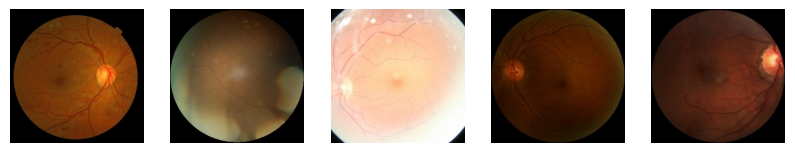

In [15]:
import random

sample_paths = list(Path(clean_train_dir).rglob("*.*"))

plt.figure(figsize=(10,5))

for i in range(5):

    img_path = random.choice(sample_paths)

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

### Final Dataset Statistics

Total Training Images: 4145
Total Validation Images: 73
Total Images: 4218


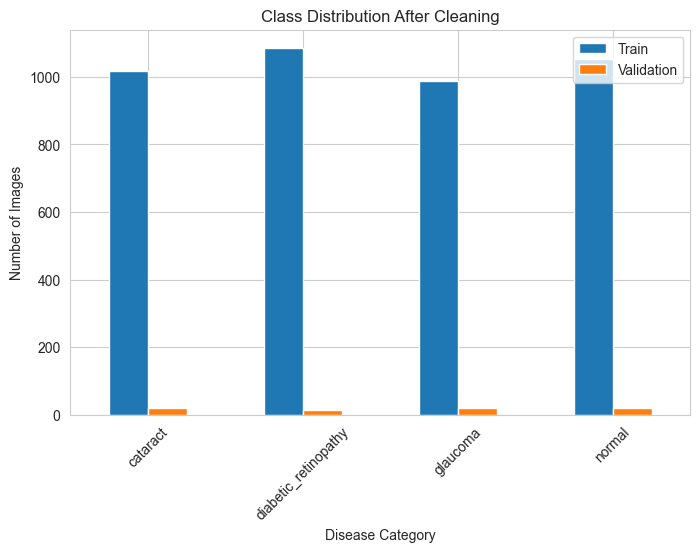

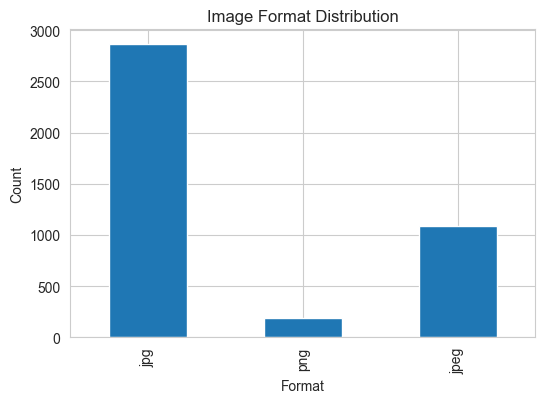

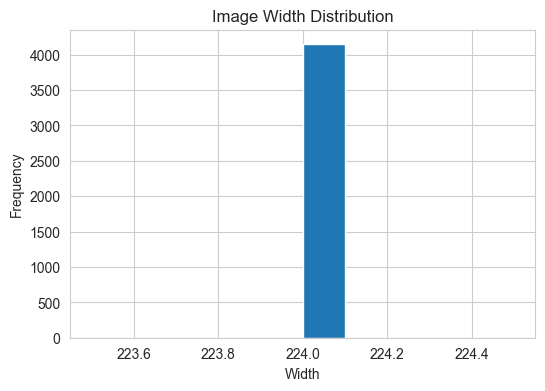

Original Range: 0 - 147
Normalized Range: 0.0 - 0.5764705882352941


In [16]:
# Total images
# ============
train_total = sum(len(files) for _,_,files in os.walk(clean_train_dir))
val_total = sum(len(files) for _,_,files in os.walk(clean_val_dir))

print("Total Training Images:", train_total)
print("Total Validation Images:", val_total)
print("Total Images:", train_total + val_total)

# Class Distribution Table
# =========================
train_counts = count_images(clean_train_dir)
val_counts = count_images(clean_val_dir)

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts
})

df_counts

# Class Distribution Graph
# ========================
df_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Class Distribution After Cleaning")
plt.ylabel("Number of Images")
plt.xlabel("Disease Category")
plt.xticks(rotation=45)
plt.show()

# Image Format Distribution
# =========================
format_counts = {}

for root, dirs, files in os.walk(clean_train_dir):
    for file in files:
        ext = file.split(".")[-1].lower()
        format_counts[ext] = format_counts.get(ext,0) + 1

df_formats = pd.DataFrame.from_dict(
    format_counts,
    orient="index",
    columns=["Count"]
)

df_formats

# Format Distribution Graph
# ========================
df_formats.plot(
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Image Format Distribution")
plt.ylabel("Count")
plt.xlabel("Format")
plt.show()

# Image Dimension Statistics
# ==========================
widths = []
heights = []

for root, dirs, files in os.walk(clean_train_dir):

    for file in files:

        img = cv2.imread(os.path.join(root,file))
        h,w,_ = img.shape

        heights.append(h)
        widths.append(w)

df_dimensions = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

df_dimensions.describe()

# Image Dimension Distribution
# ============================
plt.figure(figsize=(6,4))

plt.hist(widths, bins=10)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

# Pixel Normalization Verification
# ================================
sample = cv2.imread(str(list(Path(clean_train_dir).rglob("*.*"))[0]))

normalized = sample / 255.0

print("Original Range:", sample.min(), "-", sample.max())
print("Normalized Range:", normalized.min(), "-", normalized.max())